# Speed and Structure challenge
### Racing to Uncover Earth's Subsurface 🏎️💨

Get ready to rev your engines and race to the subsurface! Welcome to the Speed and Structure challenge, an exhilarating journey that puts you in the driver's seat to pioneer cutting-edge techniques for seismic velocity inversion.

Your mission? To construct high-resolution models of subsurface velocities directly from seismic data. Imagine yourself as a high-tech cartographer of the underworld, transforming complex seismic signals—the very echoes of our planet—into detailed velocity maps. By doing so, you'll be unlocking invaluable insights into the Earth's hidden architecture, revealing geological formations crucial for everything from resource exploration to hazard assessment. This isn't just about listening to the Earth; it's about understanding its intricate inner workings with incredible precision and speed.

This challenge calls for your expertise in navigating complex datasets and your ingenuity in applying or even inventing innovative algorithms, potentially leveraging the power of deep learning, generative models, or hybrid approaches. You'll be tasked with overcoming hurdles like cycle-skipping and the ill-posed nature of traditional inversion methods, pushing the boundaries of what's possible in geophysical interpretation.

And there's more! As you develop robust and efficient algorithms to accurately map the subterranean velocity landscape, you'll be contributing to a deeper understanding of our planet. Your work will play a crucial role in advancing geophysical research and could lead to groundbreaking discoveries, helping us better understand and utilize the Earth's resources responsibly.

So, are you ready to take on the challenge, push the limits of speed and accuracy, and make your mark in the world of seismic interpretation? Let's dive in and start uncovering the true speed and structure of our planet!

### Supplied Materials:

*  Starter Notebook
*  Train dataset: comprises 2000 samples, each organized within its own uniquely named folder corresponding to the sample ID. Within each folder are six 2D NumPy array (`.npy`) files:

    * Five input (feature) files represent synthetic seismic survey data. These are named using the pattern: `receiver_data_src_<i>.npy`, where `<i>` denotes the relative position of the seismic source and takes one of the following values: [1, 75, 150, 225, 300].

    * One target file, named `vp_model.npy`, contains the ground-truth subsurface velocity model associated with the corresponding seismic inputs.

* Test dataset: comprises 150 samples, each organized similarly to the training set. Every sample includes five input (feature) files representing synthetic seismic survey data. These files follow the same naming convention as in the training dataset. Unlike the training dataset, the test set does not include the target file (vp_model.npy). Your prediction for this dataset will be used to calculate your score for the predictive leaderboard.

*  `utils.py`: containing some functions used in this starter notebook and to help you get started.
*  `requirements.txt`: this file should contain all the required packages for your submission.

## Understanding the Data: A Glimpse into Seismic Surveys

To understand what lies hidden beneath the Earth's surface, whether deep underground or beneath the ocean floor, geophysicists conduct seismic surveys. Imagine a process somewhat like medical ultrasound, but on a vastly larger scale, designed to create an "image" of the subsurface geology.

As illustrated in the schematic image below, a specialized survey ship typically tows an energy source (like an "air gun") and a series of sensitive underwater microphones called "hydrophones." The air gun releases a powerful burst of sound waves that travel down through the water and into the seabed. These waves continue to propagate deeper, penetrating through various geological layers – different types of rock, sediments, and potentially encountering reservoirs containing oil, gas, or water. When these sound waves encounter a boundary between different materials (e.g., where one type of rock layer ends and another begins, or where fluid content changes), a portion of their energy is reflected back towards the surface.

These returning "echoes" are then detected and meticulously recorded by the hydrophones. Each set of recordings from a single burst of the air gun, captured by the array of hydrophones, is essentially a snapshot of how the sound waves have interacted with the subsurface. In this challenge, the input files you'll be working with (e.g., `receiver_data_src_1.npy`, `receiver_data_src_75.npy`, etc.) represent this synthetic seismic survey data. Each file corresponds to the data recorded from a series of receivers for a specific shot or relative position of the sound source. The target file (`vp_model.npy`) is the "ground truth" – it's the actual map of how fast those sound waves travel through the different materials in the subsurface (the velocity model). Your task is to use the recorded seismic signals (the input) to reconstruct this detailed velocity model (the target), effectively creating a high-resolution picture of the Earth's hidden structures.

Kukreja, Navjot & Louboutin, Mathias & Lange, Michael & Luporini, Fabio & Gorman, G.. (2017). Rapid Development of Seismic Imaging Applications Using Symbolic Math. 10.3997/2214-4609.201702315.

![alt text](offshore-seismic-survey.png "Offshore seismic survey")



# Imports
REMEMBER TO ADD YOUR PACKAGES TO the requirements.txt

In [4]:
pip install anytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.0 MB/s eta 0:00:00


In [5]:
import numpy as np
from anytree import Node, RenderTree
from typing import Dict, List


def dummy_prediction(input_data, output_shape):
    """
    Generates a dummy prediction for velocity model.

    Parameters:
    input_data: list of 5 2D receiver data np.ndarrays

    Returns:
    prediction: A 2D np.ndarray with velocity model prediction
    """
    prediction = np.random.choice(np.linspace(1, 5, 20, dtype=np.float64), size=output_shape)

    return prediction


def create_submission(sample_id: str, prediction: np.ndarray, submission_path: str):
    """Function to create submission file out of one test prediction at time

    Parameters:
        sample_id: filename
        prediction: 2D np.ndarray of predicted velocity model
        submission_path: path to save submission

    Returns:
        None
    """

    try:
        submission = dict(np.load(submission_path))
    except:
        submission = dict({})

    submission.update(dict({sample_id: prediction}))

    np.savez(submission_path, **submission)

    return

def sketch_directory_tree():
    # Create nodes for the directory structure
    root = Node("current_directory")
    starter_notebook = Node("starter_notebook.ipynb", parent=root)
    utils = Node("utils.py", parent=root)
    data = Node("data", parent=root)
    train = Node("train", parent=data)
    test = Node("test", parent=data)

    # Render the directory tree
    for pre, fill, node in RenderTree(root):
        print("%s%s" % (pre, node.name))
    return


def calculate_mape(vel_gt: np.ndarray, vel_pred: np.ndarray) -> float:
    """
    Calculates the Mean Absolute Percentage Error between two 2D NumPy arrays
    of the SAME size.

    The error for each element (i,j) is calculated as:
        abs(vel_gt[i,j] - vel_pred[i,j]) / (vel_gt[i,j] + EPSILON)
    EPSILON is added to the denominator to prevent division by zero.

    Args:
        vel_gt: A 2D NumPy array representing the ground truth values.
        vel_pred: A 2D NumPy array representing the predicted values.
                  Must have the same shape as vel_gt.

    Returns:
        The mean of the normalized absolute errors.
    """
    # Define a small epsilon to prevent division by zero
    EPSILON = 1e-8

    # Calculate the absolute difference element-wise
    absolute_difference = np.abs(vel_gt - vel_pred)

    # Calculate the normalized error element-wise
    # Add EPSILON to vel_gt in the denominator to avoid division by zero
    # and to handle cases where vel_gt[i,j] is 0.
    # If vel_gt[i,j] is 0 and vel_pred[i,j] is also 0, error is 0.
    # If vel_gt[i,j] is 0 and vel_pred[i,j] is non-zero, error is large.
    normalized_error = absolute_difference / (np.abs(vel_gt) + EPSILON)

    # Calculate the mean of the normalized errors
    mape = np.mean(normalized_error)

    return mape

def calculate_score(answerkey_file: str, submission_file: str) -> float:
    """
    Calculates the average mape across multiple samples.

    This function iterates through pairs of groundtruth and predicted velocity models
    stored in npz files. It calculates MAPE for each pair
    using the `calculate_mape` function.

    The final score is the average MAPE over all samples.

    Args:
        answerkey_file: an npz file where keys are string sample identifiers (e.g., IDs)
                   and values are 2D NumPy arrays representing the ground truth
                   velocity models.
        submission_file: an npz file with string keys, ideally matching `answerkey`,
                    where values are 2D NumPy arrays representing the predicted
                    velocity models.

    Returns:
        The average MAPE score across all samples.
    """
    answerkey =  dict(np.load(answerkey_file))
    submission =  dict(np.load(submission_file))

    mape_samples: List[float] = [] # List to store MAPE for samples

    # Iterate through the keys (sample IDs) in the answer key
    for key in answerkey.keys():

        # Retrieve the ground truth and predicted arrays for the current key
        vel_gt = answerkey[key]
        vel_pred = submission[key]

        # Calculate the MAPE for the current sample using the helper function
        mape_score = calculate_mape(vel_gt, vel_pred)
        mape_samples.append(mape_score)

    return float(np.mean(mape_samples))

In [6]:
import os
import sys
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from anytree import Node, RenderTree
from typing import Dict, List

from utils import *

# Data

You can download the train and test data from the challenge’s webpage or portal under the data tab.

Let's assume that you have downloaded the train and test data, and organized them as shown in the tree below.

<b>Note:</b> For demonstration purposes in this starter notebook, only a subset of the full dataset is included: 5 samples in the train folder and 4 samples in the test folder.  Please note that in the complete dataset, these numbers will be expanded to 2000 training samples and 150 test samples, respectively.

In [7]:
sketch_directory_tree()

current_directory
├── starter_notebook.ipynb
├── utils.py
└── data
    ├── train
    └── test


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!cp -r /content/drive/MyDrive/speed-and-structure-train-data.zip /content/local_data/

In [7]:
!unzip /content/local_data/speed-and-structure-train-data.zip -d /content/local_data/dataset/

Streaming output truncated to the last 5000 lines.
  inflating: /content/local_data/dataset/cQDPayDywaXCXmqy2N/receiver_data_src_1.npy  
  inflating: /content/local_data/dataset/cQDPayDywaXCXmqy2N/receiver_data_src_75.npy  
   creating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/receiver_data_src_150.npy  
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/vp_model.npy  
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/receiver_data_src_225.npy  
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/receiver_data_src_300.npy  
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/receiver_data_src_1.npy  
  inflating: /content/local_data/dataset/cS4T3yIXu9ZTNtXcak/receiver_data_src_75.npy  
   creating: /content/local_data/dataset/cS5162zA46neO0qk7a/
  inflating: /content/local_data/dataset/cS5162zA46neO0qk7a/receiver_data_src_150.npy  
  inflating: /content/local_data/dataset/cS5162zA46neO


Below, we begin by listing the sample IDs for the five samples included in the `train` folder. We then display the file names contained within the first sample directory.

As outlined earlier in the **Supplied Materials** section, each sample contains:

- **Five input (feature) files** named `receiver_data_src_<i>.npy`, where `<i>` indicates the source position.
- **One target file**, `vp_model.npy`, which represents the ground-truth subsurface velocity model.


In [8]:
# Directory path
training_dataset = "/content/local_data/*"  # 'path to your training data'

# List to store the names of subfolders (sample IDs)
sample_paths = glob(training_dataset)
# extract the name of samples, i.e. sample IDs
sample_ids = [path.split("/")[-1] for path in sample_paths]
sample_ids

['motCQiFZSmLXzRpFUl',
 '0jyYHm7HPeS92ytcTn',
 'z5QPAwzxOSOon3HFlF',
 'QPg2TS7uw1b39lqDfG',
 'hpJzSCYDwqYfLlyTg8',
 '5ITLa3ukSVwiyybVU3',
 'ApUtVoWktCPB2rTfkH',
 'Fz9cbbzylTurY3itR5',
 'se9P3oVkRrd0sVvUyD',
 'oo0uleBySUGrIaYB2B',
 'MX2UTZlzJK7LhATBoe',
 '00ady8InZofxhWZsDT',
 'h6sCF84tP2QuRCbwa5',
 'PTNw1dS7rYppPYDlaq',
 'M3CDXpEsUYabi82Uz3',
 '267r7kaQSZMZPByqe8',
 'CWVLDQ0xIImdObehp8',
 '65tqJ7ieyoo0qrbQNz',
 'qT6mmfOQGhkYceRXjB',
 'h92dVP8LIL5TE09QPE',
 '3qSf2s3G71IpXJXu3S',
 'AsTMsaToXAdr1WpQUp',
 'Paa7eglHWZKMGqSPdl',
 '8lWRRAkMOI8YO0o5Ca',
 'kND19jT4Oa3RLnpN4M',
 'sobZViEval1O3O2UQy',
 '7YbTI4wJAKiXL9HVIk',
 'qzLQZWf12og5ZBAOdh',
 'onxdlLvgMjwY11SW2V',
 'Zu8Bg22kzIGZSH9iqy',
 'S5L5907yhaCW9cJW5e',
 'LHOQAKZg3wYWC8Y3Qm',
 'byKNfRxlxgho4nX5ej',
 'XBUXJQj01AwUhtpV1e',
 'Yb9DSlq935AM1XlS45',
 '0db6lvl7hjfE9koOpa',
 '8K7qnz9XLGZRHAPAx0',
 'bTtkEpoScMFSyJAaI7',
 'vwJLOAWW5MZtSwkl3g',
 'vMcm3w1wgzMGnmQDot',
 'g1BoDSZczsNEolCvg7',
 '9sxIqd6sWfnMeC5ArD',
 'Kw4UhosWy4SRQ2d0O7',
 'OLcSxmCPq

In [ ]:
!unzip "/content/drive/MyDrive/speed-and-structure-test-data.zip" -d "/content/drive/MyDrive/speed_and_structure_datatest/"

Archive:  /content/drive/MyDrive/speed-and-structure-test-data.zip
   creating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/receiver_data_src_150.npy  
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/receiver_data_src_225.npy  
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/receiver_data_src_300.npy  
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/receiver_data_src_1.npy  
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0BFqBxnVIT368FwmdR/receiver_data_src_75.npy  
   creating: /content/drive/MyDrive/speed_and_structure_datatest/0yONYjTWNAfKjAilsA/
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0yONYjTWNAfKjAilsA/receiver_data_src_150.npy  
  inflating: /content/drive/MyDrive/speed_and_structure_datatest/0yONYjTWNAfKjAilsA/receiver_d

In [9]:
# List all file names for the first sample
file_names = os.listdir(sample_paths[0])
file_names

['receiver_data_src_300.npy',
 'vp_model.npy',
 'receiver_data_src_75.npy',
 'receiver_data_src_150.npy',
 'receiver_data_src_225.npy',
 'receiver_data_src_1.npy']

> **Note:**  
> All receiver data, regardless of the source position, are stored as 2D NumPy arrays with shape **(10001, 31)**.  
> - The **31 columns** correspond to individual receivers.  
> - The **rows** represent time steps in the recording.  
> - Thus, `receiver_data[i, j]` indicates the signal recorded by the **j-th receiver** at the **i-th time unit**.
>
> All target data (velocity models) are also 2D NumPy arrays with shape **(300, 1259)**.  
> - The **columns** (second axis) represent the **vertical physical axis** in the subsurface (i.e., depth).  
> - The **rows** (first axis) represent the **horizontal physical axis**.  
> - Therefore, `target_data[i, j]` gives the wave velocity at a point located **i units horizontally** and **j units in depth** from the measurement origin.


In [10]:
# single source np.ndarray
rec_data = np.load(os.path.join(sample_paths[0], f"receiver_data_src_1.npy"))
print("Receiver data shape:", rec_data.shape)
# target velocity model
target_data = np.load(os.path.join(sample_paths[0], "vp_model.npy"))
print("Target data shape:", target_data.shape)

Receiver data shape: (10001, 31)
Target data shape: (300, 1259)


Using base_train_data_path: /content/drive/MyDrive/speed_and_structure_data/
Found 2000 sample folders.

--- Exploring Sample 1: 00ady8InZofxhWZsDT ---
Input Seismic Data:
  receiver_data_src_1.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=-0.00, Std=0.01
  receiver_data_src_75.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.22, Mean=-0.00, Std=0.02
  receiver_data_src_150.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=-0.00, Std=0.02
  receiver_data_src_225.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.22, Mean=-0.00, Std=0.02
  receiver_data_src_300.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=-0.00, Std=0.01

Target Velocity Model:
  vp_model.npy: Shape=(300, 1259), Dtype=float64, Min=1.50, Max=4.09, Mean=2.78, Std=0.93


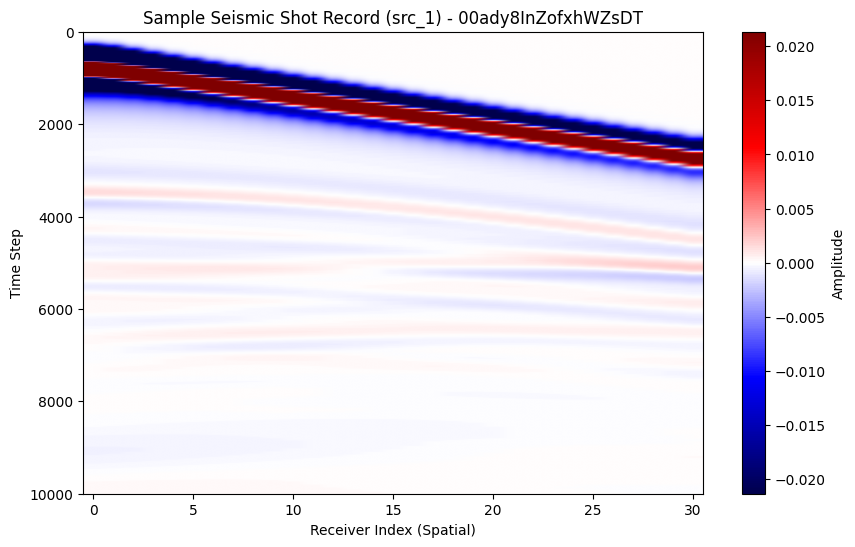

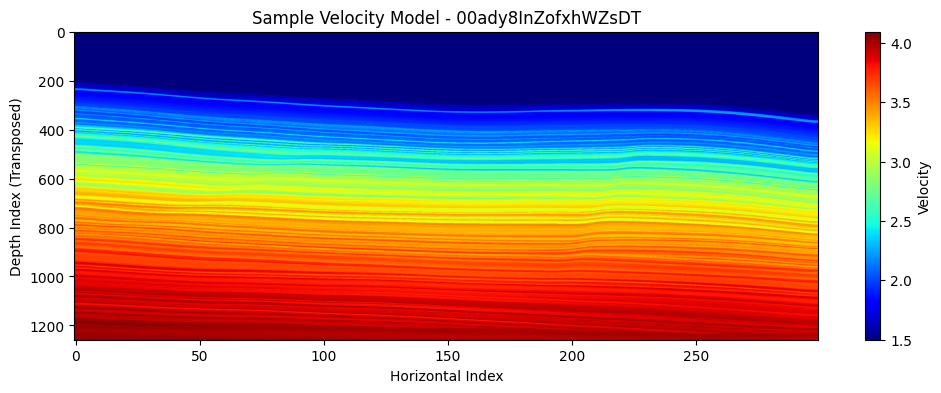

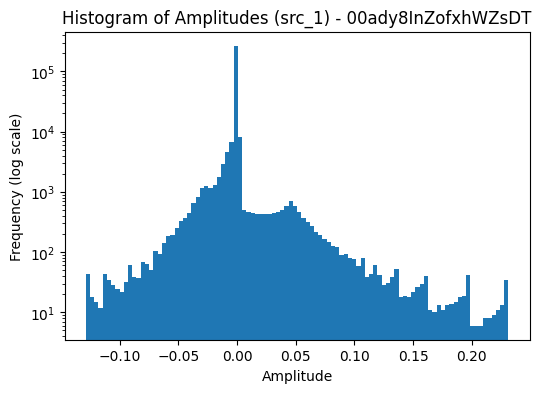

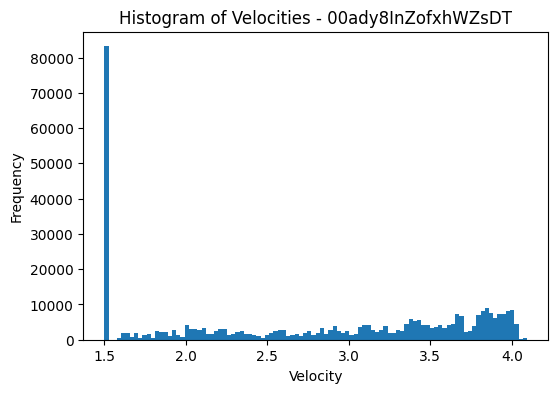


--- Exploring Sample 2: 01BOBpFpr5YkZhAs32 ---
Input Seismic Data:
  receiver_data_src_1.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=0.00, Std=0.01
  receiver_data_src_75.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.22, Mean=0.00, Std=0.02
  receiver_data_src_150.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=0.00, Std=0.02
  receiver_data_src_225.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.22, Mean=0.00, Std=0.02
  receiver_data_src_300.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=0.00, Std=0.01

Target Velocity Model:
  vp_model.npy: Shape=(300, 1259), Dtype=float64, Min=1.50, Max=4.17, Mean=3.02, Std=0.89

--- Exploring Sample 3: 02IVRi2gRJYQHuh9Gp ---
Input Seismic Data:
  receiver_data_src_1.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.23, Mean=-0.00, Std=0.01
  receiver_data_src_75.npy: Shape=(10001, 31), Dtype=float32, Min=-0.13, Max=0.22, Mean=-0.00, Std=0.02
  receiver_data_src_150.np

In [11]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import torch

# --- IMPORTANT: Confirm and Set Your Data Paths ---
# Based on our previous discussions, after unzipping, the sample ID folders
# (e.g., 'zbXKR3RYd4YRlsXIzc') should be directly inside a main directory.
# Please verify this path carefully in your Google Drive and update it.

# Option 1: If sample ID folders are directly in 'speed_and_structure_data'
# (e.g., /content/drive/MyDrive/speed_and_structure_data/zbXKR3RYd4YRlsXIzc/)
# base_train_data_path = "/content/drive/MyDrive/speed_and_structure_data/"

# Option 2: If unzipping created a 'train' subfolder inside 'speed_and_structure_data'
# (e.g., /content/drive/MyDrive/speed_and_structure_data/train/zbXKR3RYd4YRlsXIzc/)
# This is a common structure for training datasets.
base_train_data_path = "/content/drive/MyDrive/speed_and_structure_data/" #<-- EXAMPLE, PLEASE VERIFY!

# If your structure is different, adjust base_train_data_path accordingly.
# For example, if the 'train' folder is one level higher:
# base_train_data_path = "/content/drive/MyDrive/train/" # where 'train' contains the sample_id folders

# Check if the path exists
if not os.path.exists(base_train_data_path):
    print(f"ERROR: The path '{base_train_data_path}' does not exist. Please verify your unzipped data structure.")
    # You might need to list directories to find the correct path, e.g.:
    # !ls "/content/drive/MyDrive/"
    # !ls "/content/drive/MyDrive/speed_and_structure_data/"
else:
    print(f"Using base_train_data_path: {base_train_data_path}")

    # Get a list of all sample ID folders
    # The pattern should match the sample ID folders directly.
    all_sample_folder_paths = sorted(glob.glob(os.path.join(base_train_data_path, "*"))) # The '*' lists directories within

    if not all_sample_folder_paths:
        print(f"ERROR: No sample folders found in '{base_train_data_path}'.")
        print("Please ensure that 'base_train_data_path' points to the directory CONTAINING the individual sample ID folders (e.g., 'zbXKR3RYd4YRlsXIzc', ...).")
        print(f"For example, if your structure is /content/drive/MyDrive/data_root/train/SAMPLE_ID_FOLDER/, then base_train_data_path should be /content/drive/MyDrive/data_root/train/")
    else:
        print(f"Found {len(all_sample_folder_paths)} sample folders.")
        # Let's pick the first few sample folders for EDA
        sample_folders_for_eda = all_sample_folder_paths[:3] # Explore first 3 samples

        for i, sample_folder_path in enumerate(sample_folders_for_eda):
            print(f"\n--- Exploring Sample {i+1}: {os.path.basename(sample_folder_path)} ---")

            # Define source coordinates
            source_coords = [1, 75, 150, 225, 300]
            input_seismic_data = []

            # Load the 5 input seismic shot records
            print("Input Seismic Data:")
            for s_coord in source_coords:
                file_path = os.path.join(sample_folder_path, f"receiver_data_src_{s_coord}.npy")
                if os.path.exists(file_path):
                    shot_data = np.load(file_path)
                    input_seismic_data.append(shot_data)
                    print(f"  receiver_data_src_{s_coord}.npy: Shape={shot_data.shape}, Dtype={shot_data.dtype}, Min={shot_data.min():.2f}, Max={shot_data.max():.2f}, Mean={shot_data.mean():.2f}, Std={shot_data.std():.2f}")
                else:
                    print(f"  ERROR: File not found - {file_path}")
                    input_seismic_data.append(None) # Placeholder for missing file

            # Load the target velocity model
            print("\nTarget Velocity Model:")
            vp_model_path = os.path.join(sample_folder_path, "vp_model.npy")
            if os.path.exists(vp_model_path):
                vp_model_data = np.load(vp_model_path)
                print(f"  vp_model.npy: Shape={vp_model_data.shape}, Dtype={vp_model_data.dtype}, Min={vp_model_data.min():.2f}, Max={vp_model_data.max():.2f}, Mean={vp_model_data.mean():.2f}, Std={vp_model_data.std():.2f}")

                # --- Visualizations (for the first sample only to avoid too many plots) ---
                if i == 0:
                    # Visualize one seismic shot record
                    if input_seismic_data[0] is not None: # Check if the first shot loaded
                        plt.figure(figsize=(10, 6))
                        plt.imshow(input_seismic_data[0], aspect='auto', cmap='seismic', vmin=-np.percentile(np.abs(input_seismic_data[0]),95), vmax=np.percentile(np.abs(input_seismic_data[0]),95))
                        plt.title(f"Sample Seismic Shot Record (src_{source_coords[0]}) - {os.path.basename(sample_folder_path)}")
                        plt.xlabel("Receiver Index (Spatial)")
                        plt.ylabel("Time Step")
                        plt.colorbar(label="Amplitude")
                        plt.show()

                    # Visualize the velocity model
                    plt.figure(figsize=(12, 4))
                    plt.imshow(vp_model_data.T, aspect='auto', cmap='jet') # Transpose for typical geophysical display (depth vs horizontal)
                    plt.title(f"Sample Velocity Model - {os.path.basename(sample_folder_path)}")
                    plt.xlabel("Horizontal Index")
                    plt.ylabel("Depth Index (Transposed)")
                    plt.colorbar(label="Velocity")
                    plt.show()

                    # Histograms (for the first sample)
                    if input_seismic_data[0] is not None:
                        plt.figure(figsize=(6, 4))
                        plt.hist(input_seismic_data[0].ravel(), bins=100, log=True)
                        plt.title(f"Histogram of Amplitudes (src_{source_coords[0]}) - {os.path.basename(sample_folder_path)}")
                        plt.xlabel("Amplitude")
                        plt.ylabel("Frequency (log scale)")
                        plt.show()

                    plt.figure(figsize=(6, 4))
                    plt.hist(vp_model_data.ravel(), bins=100)
                    plt.title(f"Histogram of Velocities - {os.path.basename(sample_folder_path)}")
                    plt.xlabel("Velocity")
                    plt.ylabel("Frequency")
                    plt.show()
            else:
                print(f"  ERROR: vp_model.npy not found in {sample_folder_path}")

In [12]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split # For splitting data

# --- Configuration & Paths (from Task 1.1) ---
# Ensure this path correctly points to the directory containing the sample ID folders
base_train_data_path = "/content/drive/MyDrive/speed_and_structure_data/"
all_sample_folder_paths = sorted(glob.glob(os.path.join(base_train_data_path, "*")))

if not all_sample_folder_paths:
    print(f"ERROR: No sample folders found in '{base_train_data_path}'. Stopping.")
    # Exit or raise error if no data found, as subsequent code will fail
    # For Colab, you might just print and let the user fix the path.
else:
    print(f"Found {len(all_sample_folder_paths)} total samples.")

    # --- SeismicDataset Class ---
    class SeismicDataset(Dataset):
        def __init__(self, sample_folder_paths, target_dtype=torch.float32, input_dtype=torch.float32):
            """
            Args:
                sample_folder_paths (list of str): List of paths to individual sample folders.
                target_dtype (torch.dtype): Desired dtype for target velocity models.
                input_dtype (torch.dtype): Desired dtype for input seismic data.
            """
            self.sample_folder_paths = sample_folder_paths
            self.source_coords = [1, 75, 150, 225, 300]
            self.target_dtype = target_dtype
            self.input_dtype = input_dtype
            self.epsilon = 1e-8 # For safe division in normalization

        def __len__(self):
            return len(self.sample_folder_paths)

        def __getitem__(self, idx):
            if torch.is_tensor(idx):
                idx = idx.tolist()

            sample_folder_path = self.sample_folder_paths[idx]

            # 1. Load and preprocess 5 input seismic shot records
            stacked_seismic_data = []
            for s_coord in self.source_coords:
                file_path = os.path.join(sample_folder_path, f"receiver_data_src_{s_coord}.npy")
                shot_data = np.load(file_path) # Loads as float32 by default

                # Per-shot normalization (standardization: zero mean, unit variance)
                mean = np.mean(shot_data)
                std = np.std(shot_data)
                normalized_shot_data = (shot_data - mean) / (std + self.epsilon)

                stacked_seismic_data.append(normalized_shot_data)

            # Stack along a new "channel" dimension (first dimension for PyTorch Conv2D)
            # Resulting shape: (num_shots, time_steps, num_receivers) -> (5, 10001, 31)
            stacked_seismic_data_np = np.stack(stacked_seismic_data, axis=0)

            # 2. Load and preprocess target velocity model
            vp_model_path = os.path.join(sample_folder_path, "vp_model.npy")
            vp_model_data_np = np.load(vp_model_path) # Loads as float64

            # Add a channel dimension (first dimension for PyTorch Conv2D)
            # Resulting shape: (1, depth_samples, horizontal_samples) -> (1, 300, 1259)
            vp_model_data_np_ch = np.expand_dims(vp_model_data_np, axis=0)

            # 3. Convert to PyTorch tensors with specified dtypes
            seismic_tensor = torch.tensor(stacked_seismic_data_np, dtype=self.input_dtype)
            velocity_tensor = torch.tensor(vp_model_data_np_ch, dtype=self.target_dtype)

            return seismic_tensor, velocity_tensor

    # --- Splitting Data into Training and Validation Sets ---
    # (Only if all_sample_folder_paths is not empty)
    if all_sample_folder_paths:
        train_paths, val_paths = train_test_split(
            all_sample_folder_paths,
            test_size=0.2,        # 20% for validation
            random_state=42,      # For reproducibility
            shuffle=True
        )
        print(f"Training samples: {len(train_paths)}, Validation samples: {len(val_paths)}")

        # --- Instantiate Datasets ---
        train_dataset = SeismicDataset(train_paths)
        val_dataset = SeismicDataset(val_paths)

        # --- Instantiate DataLoaders ---
        batch_size = 4 # You can adjust this later based on GPU memory and model size
        num_workers = 2 # Number of subprocesses to use for data loading (0 means main process)
                        # On Colab, 2 is often a good starting point.

        train_dataloader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,        # Shuffle training data each epoch
            num_workers=num_workers,
            pin_memory=True      # Helps speed up host-to-GPU transfers if using CUDA
        )

        val_dataloader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,       # No need to shuffle validation data
            num_workers=num_workers,
            pin_memory=True
        )

        # --- Test the DataLoaders (Optional but Recommended) ---
        print("\nTesting DataLoaders...")
        # Get one batch from the training DataLoader
        try:
            train_features_batch, train_labels_batch = next(iter(train_dataloader))
            print(f"Shape of a training features batch: {train_features_batch.size()}") # Expected: (batch_size, 5, 10001, 31)
            print(f"Dtype of a training features batch: {train_features_batch.dtype}")
            print(f"Shape of a training labels batch: {train_labels_batch.size()}")   # Expected: (batch_size, 1, 300, 1259)
            print(f"Dtype of a training labels batch: {train_labels_batch.dtype}")

            # Get one batch from the validation DataLoader
            val_features_batch, val_labels_batch = next(iter(val_dataloader))
            print(f"Shape of a validation features batch: {val_features_batch.size()}")
            print(f"Dtype of a validation features batch: {val_features_batch.dtype}")
            print(f"Shape of a validation labels batch: {val_labels_batch.size()}")
            print(f"Dtype of a validation labels batch: {val_labels_batch.dtype}")
        except Exception as e:
            print(f"Error testing DataLoader: {e}")
            print("This might happen if num_workers > 0 in a non-script environment on some systems, or if sample_folder_paths was empty.")

Found 2000 total samples.
Training samples: 1600, Validation samples: 400

Testing DataLoaders...
Shape of a training features batch: torch.Size([4, 5, 10001, 31])
Dtype of a training features batch: torch.float32
Shape of a training labels batch: torch.Size([4, 1, 300, 1259])
Dtype of a training labels batch: torch.float32
Shape of a validation features batch: torch.Size([4, 5, 10001, 31])
Dtype of a validation features batch: torch.float32
Shape of a validation labels batch: torch.Size([4, 1, 300, 1259])
Dtype of a validation labels batch: torch.float32


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Define Basic Convolutional Block ---
class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False), # bias=False because BN follows
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

# --- Define Downsampling Block (Encoder Path) ---
class Down(nn.Module):
    """Downscaling with MaxPool then DoubleConv"""
    def __init__(self, in_channels, out_channels, pool_kernel_stride=(2, 2)):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(pool_kernel_stride[0], stride=pool_kernel_stride[1]), # Allow for asymmetric pooling
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

# --- Define Upsampling Block (Decoder Path) ---
class Up(nn.Module):
    """Upscaling then DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True, upsample_scale_factor=(2,2)):
        super().__init__()
        self.upsample_scale_factor = upsample_scale_factor
        # If bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=upsample_scale_factor, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2) # mid_channels = in_channels // 2
        else:
            # Use ConvTranspose2d with stride matching scale_factor for learnable upsampling
            # kernel_size must also be chosen appropriately. A common choice is kernel_size = scale_factor
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2,
                                         kernel_size=upsample_scale_factor,
                                         stride=upsample_scale_factor)
            self.conv = DoubleConv(in_channels, out_channels) # After concat, channels are in_channels

    def forward(self, x1, x2): # x1 from upsampling, x2 from skip connection
        x1 = self.up(x1)
        # Input is CHW
        # Handle potential padding issues if x1 and x2 shapes don't perfectly align after upsampling
        # This is common in U-Nets, especially with asymmetric inputs/outputs or many pooling layers.
        # We will crop x2 (from skip connection) to match x1's spatial dimensions.
        diffY = x2.size()[2] - x1.size()[2] # Difference in Height dimension
        diffX = x2.size()[3] - x1.size()[3] # Difference in Width dimension

        # Pad x1 if it's smaller, or crop x2 if it's larger. Cropping x2 is generally safer.
        # Here we assume x1 might be slightly smaller or equal due to pooling/upsampling arithmetic.
        # Let's try a central crop on x2.
        if diffY > 0 or diffX > 0: # if x2 is larger
            x2 = x2[:, :, diffY // 2 : x2.size()[2] - diffY // 2 - (diffY % 2), # Handle odd/even diff
                           diffX // 2 : x2.size()[3] - diffX // 2 - (diffX % 2)]

        # Alternative: Pad x1 if necessary (more complex if dimensions are not easily predictable)
        # x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
        #                 diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1) # Concatenate along channel dimension
        return self.conv(x)

# --- Define Output Convolution Layer ---
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# --- Assemble the U-Net Model ---
class BaselineUNet(nn.Module):
    def __init__(self, n_channels_in, n_channels_out, bilinear=True):
        super(BaselineUNet, self).__init__()
        self.n_channels_in = n_channels_in
        self.n_channels_out = n_channels_out
        self.bilinear = bilinear

        # Encoder
        # Input: (N, 5, 10001, 31)
        self.inc = DoubleConv(n_channels_in, 64)                          # Output: (N, 64, 10001, 31)

        # Asymmetric pooling to handle the large height (10001) and small width (31)
        # Pool kernel/stride arguments are (height_factor, width_factor)
        self.down1 = Down(64, 128,   pool_kernel_stride=((4,2), (4,1)))    # Output: (N, 128, 2500, 31) -> check W carefully: 31/1 = 31
        self.down2 = Down(128, 256,  pool_kernel_stride=((4,2), (4,1)))    # Output: (N, 256, 625, 31)
        self.down3 = Down(256, 512,  pool_kernel_stride=((5,2), (5,1)))    # Output: (N, 512, 125, 31)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor, pool_kernel_stride=((5,2), (5,1)))# Output: (N, 512 or 1024, 25, 31) -> Bottleneck

        # Decoder
        # Target output H_out=300, W_out=1259
        # The upsampling factors need careful calculation to reach the target output.
        # This will require some trial and error or precise calculation of padding/cropping in Up blocks.
        # Current bottleneck might be (N, 512, 25, 31) or (N, 1024, 25, 31)

        # Let's define upsampling scale factors to roughly match the downsampling
        # This is a simplified initial attempt; precise matching to 300x1259 requires care.
        self.up1 = Up(1024, 512 // factor, bilinear, upsample_scale_factor=(5,1)) # From (25,31) to (125, 31) approx
        self.up2 = Up(512, 256 // factor, bilinear, upsample_scale_factor=(5,1))  # From (125,31) to (625, 31) approx
        self.up3 = Up(256, 128 // factor, bilinear, upsample_scale_factor=(4,1))  # From (625,31) to (2500, 31) approx
        self.up4 = Up(128, 64, bilinear, upsample_scale_factor=(4,1))             # From (2500,31) to (10000, 31) approx

        self.outc = OutConv(64, n_channels_out)

        # Final adjustment layer to get exact 300x1259 output
        # This is a common trick if the U-Net output doesn't perfectly match.
        # We'll use adaptive pooling or a final interpolation + conv.
        # Current output after up4 is approx (N, 64, 10000, 31)
        # Target is (N, 1, 300, 1259)

        # Option 1: Adaptive Pooling + Conv (simpler to implement, might lose detail)
        # self.final_adjust = nn.Sequential(
        #     nn.AdaptiveAvgPool2d((300, 1259)), # Forces output to target HxW
        #     nn.Conv2d(64, n_channels_out, kernel_size=1) # Project to n_channels_out
        # )

        # Option 2: Final ConvTranspose2D or Upsample + Conv for more controlled resizing
        # This requires careful calculation. For a baseline, adaptive pooling is easier.
        # For now, let's assume the output of U-Net is (N, 64, H_intermediate, W_intermediate)
        # and we'll adjust the U-Net layers or add a final resizer.

        # Simpler: a final conv that tries to reshape with padding/cropping implicitly by `outc`
        # The `outc` above will output (N, n_channels_out, H_Unet_out, W_Unet_out)
        # We need to ensure H_Unet_out, W_Unet_out are close to 300, 1259 or use interpolation.
        # For the baseline, let's make the U-Net output something large enough and then interpolate.
        # So, after self.up4 and self.outc, the output might be (N, 1, ~10000, ~31)
        # We will add an interpolation step in the forward pass.


    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck features

        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)

        # Final resizing to target output shape (300, 1259) using interpolation
        # This is a common way to handle mismatched sizes from U-Net decoders.
        # The output of outc is (N, n_channels_out, H_final_unet, W_final_unet)
        # We expect n_channels_out = 1
        final_output = F.interpolate(logits, size=(300, 1259), mode='bilinear', align_corners=False)

        return final_output

# --- Test the Model with a Dummy Input ---
if __name__ == '__main__': # Run only if script is executed directly
    # Assuming you have the DataLoaders from Task 1.2 available or can create a dummy batch
    # For a quick test without DataLoaders:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Model parameters
    n_input_channels = 5  # 5 stacked seismic shots
    n_output_channels = 1 # 1 channel for the output velocity map

    model = BaselineUNet(n_channels_in=n_input_channels, n_channels_out=n_output_channels, bilinear=True).to(device)
    print(f"Model instantiated on {device}")
    # print(model) # Optional: Print model architecture

    # Create a dummy input batch
    # (batch_size, channels_in, height_in, width_in)
    # (batch_size, 5, 10001, 31)
    dummy_batch_size = 2
    dummy_input = torch.randn(dummy_batch_size, n_input_channels, 10001, 31).to(device, dtype=torch.float32)
    print(f"Dummy input shape: {dummy_input.shape}, dtype: {dummy_input.dtype}")

    # Perform a forward pass
    try:
        with torch.no_grad(): # No need to compute gradients for a simple test pass
            output = model(dummy_input)
        print(f"Model output shape: {output.shape}") # Expected: (dummy_batch_size, n_output_channels, 300, 1259)
        print(f"Model output dtype: {output.dtype}")
        # Check if output shape matches target
        assert output.shape == (dummy_batch_size, n_output_channels, 300, 1259)
        print("Model forward pass successful and output shape is correct!")

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total trainable parameters: {total_params:,}")

    except Exception as e:
        print(f"Error during model forward pass: {e}")
        import traceback
        traceback.print_exc()

Using device: cuda
Model instantiated on cuda
Dummy input shape: torch.Size([2, 5, 10001, 31]), dtype: torch.float32
Model output shape: torch.Size([2, 1, 300, 1259])
Model output dtype: torch.float32
Model forward pass successful and output shape is correct!
Total trainable parameters: 17,264,129


Found 2000 total samples for dataset setup.
Using device: cuda
Using num_workers = 2 for DataLoaders.
Train DataLoader: 400 batches of size 4
Validation DataLoader: 100 batches of size 4
Model, MAE Loss, and Optimizer instantiated.

Starting training for 40 epochs...
Epoch 1: New best Val MAPE: 12.6918%. Model saved.
Epoch 1/40 | Train MAE: 1.114392 | Val MAE: 0.339597 | Val MAPE: 12.6918%
Epoch 2: New best Val MAPE: 6.3480%. Model saved.
Epoch 2/40 | Train MAE: 0.227541 | Val MAE: 0.165924 | Val MAPE: 6.3480%
Epoch 3/40 | Train MAE: 0.174994 | Val MAE: 0.174077 | Val MAPE: 7.0008%
Epoch 4/40 | Train MAE: 0.159901 | Val MAE: 0.172577 | Val MAPE: 6.4227%
Epoch 5/40 | Train MAE: 0.147399 | Val MAE: 0.164729 | Val MAPE: 6.7361%
Epoch 6: New best Val MAPE: 5.7768%. Model saved.
Epoch 6/40 | Train MAE: 0.139841 | Val MAE: 0.143935 | Val MAPE: 5.7768%
Epoch 7: New best Val MAPE: 5.1941%. Model saved.
Epoch 7/40 | Train MAE: 0.133724 | Val MAE: 0.134778 | Val MAPE: 5.1941%
Epoch 8: New best V

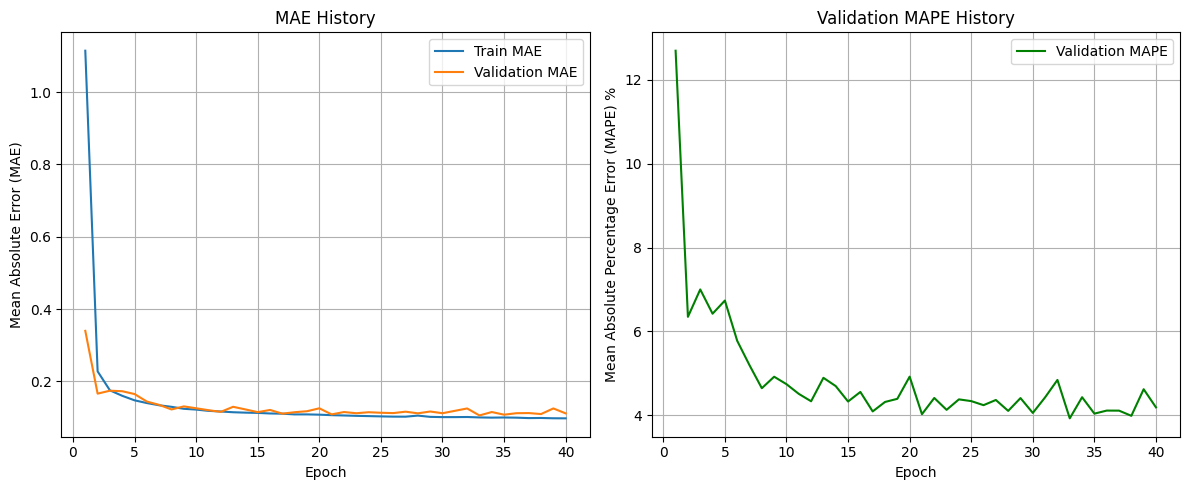

In [15]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt # For plotting losses later

# --- Ensure previous components are defined or imported ---
# Assuming SeismicDataset, BaselineUNet classes are defined in previous cells
# or imported from a utility script.

# --- MAPE Calculation Utility Function (from your utils.py) ---
def calculate_mape(vel_gt: np.ndarray, vel_pred: np.ndarray) -> float:
    """
    Calculates the Mean Absolute Percentage Error between two 2D NumPy arrays.
    EPSILON is added to the denominator to prevent division by zero.
    Args:
        vel_gt: A 2D NumPy array representing the ground truth values.
        vel_pred: A 2D NumPy array representing the predicted values.
                  Must have the same shape as vel_gt.
    Returns:
        The mean of the normalized absolute errors.
    """
    EPSILON = 1e-8
    absolute_difference = np.abs(vel_gt - vel_pred)
    # Ensure vel_gt in denominator is also abs for safety, though velocities should be positive
    normalized_error = absolute_difference / (np.abs(vel_gt) + EPSILON)
    mape = np.mean(normalized_error) * 100 # MAPE is usually expressed as a percentage
    return mape

# --- Configuration & Paths (from Task 1.1) ---
base_train_data_path = "/content/drive/MyDrive/speed_and_structure_data/"
all_sample_folder_paths = sorted(glob.glob(os.path.join(base_train_data_path, "*")))

if not all_sample_folder_paths:
    print(f"ERROR: No sample folders found. Halting training setup.")
else:
    print(f"Found {len(all_sample_folder_paths)} total samples for dataset setup.")

    # --- 1. Device Configuration ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Dataset and DataLoader Instantiation (from Task 1.2) ---
    train_paths, val_paths = train_test_split(all_sample_folder_paths, test_size=0.2, random_state=42, shuffle=True)

    train_dataset = SeismicDataset(train_paths) # Assumes SeismicDataset is defined
    val_dataset = SeismicDataset(val_paths)     # Assumes SeismicDataset is defined

    batch_size = 4 # Keep it small for now, especially if on CPU or limited GPU VRAM
    num_workers = 0 # Start with 0 for simplicity, increase later if I/O is a bottleneck and GPU is available
    if device.type == 'cuda':
      num_workers = 2 # Can use more workers if GPU is available
      print(f"Using num_workers = {num_workers} for DataLoaders.")


    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory= (device.type == 'cuda') )
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory= (device.type == 'cuda') )

    print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
    print(f"Validation DataLoader: {len(val_dataloader)} batches of size {batch_size}")


    # --- 2. Instantiate Model, Loss Function, Optimizer ---
    n_input_channels = 5
    n_output_channels = 1

    model = BaselineUNet(n_channels_in=n_input_channels, n_channels_out=n_output_channels, bilinear=True).to(device)
    # Assumes BaselineUNet is defined

    # Using MAE Loss as our initial loss for training
    criterion_mae = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4) # Start with a common learning rate

    print("Model, MAE Loss, and Optimizer instantiated.")

    # --- 3. Training and Validation Loop ---
    num_epochs = 40 # Start with a small number of epochs for initial testing
    best_val_mape = float('inf')
    train_mae_history = []
    val_mae_history = []
    val_mape_history = []

    print(f"\nStarting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train() # Set model to training mode
        running_train_mae = 0.0
        num_train_batches = 0

        for train_inputs, train_targets in train_dataloader:
            train_inputs = train_inputs.to(device)   # (batch, 5, 10001, 31)
            train_targets = train_targets.to(device) # (batch, 1, 300, 1259)

            optimizer.zero_grad() # Zero the parameter gradients

            # Forward pass
            train_outputs = model(train_inputs) # Expected output: (batch, 1, 300, 1259)

            # Calculate MAE loss
            loss_mae = criterion_mae(train_outputs, train_targets)

            # Backward pass and optimize
            loss_mae.backward()
            optimizer.step()

            running_train_mae += loss_mae.item() * train_inputs.size(0) # loss.item() is avg loss for batch
            num_train_batches += 1

        epoch_train_mae = running_train_mae / len(train_dataset)
        train_mae_history.append(epoch_train_mae)

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        running_val_mae = 0.0
        running_val_mape = 0.0
        num_val_batches = 0

        with torch.no_grad(): # Disable gradient calculations for validation
            for val_inputs, val_targets in val_dataloader:
                val_inputs = val_inputs.to(device)
                val_targets_torch = val_targets.to(device) # PyTorch tensor for MAE loss

                val_outputs_torch = model(val_inputs)

                # Calculate MAE loss (on PyTorch tensors)
                loss_val_mae = criterion_mae(val_outputs_torch, val_targets_torch)
                running_val_mae += loss_val_mae.item() * val_inputs.size(0)

                # Prepare for MAPE calculation (NumPy arrays)
                # Model output is (N, 1, H, W), target from loader is also (N, 1, H, W)
                # For calculate_mape, we need (N, H, W) or iterate sample by sample
                # Squeeze the channel dimension before converting to NumPy
                val_outputs_np = val_outputs_torch.squeeze(1).cpu().numpy()
                val_targets_np = val_targets_torch.squeeze(1).cpu().numpy()

                current_batch_mape = 0.0
                for i in range(val_outputs_np.shape[0]): # Iterate over samples in the batch
                    # calculate_mape expects 2D arrays (H, W)
                    current_batch_mape += calculate_mape(val_targets_np[i], val_outputs_np[i])

                # Average MAPE for the batch and scale by batch size (as mape is per sample)
                running_val_mape += (current_batch_mape / val_outputs_np.shape[0]) * val_inputs.size(0)
                num_val_batches +=1

        epoch_val_mae = running_val_mae / len(val_dataset)
        epoch_val_mape = running_val_mape / len(val_dataset) # Already scaled by batch size contributions
        val_mae_history.append(epoch_val_mae)
        val_mape_history.append(epoch_val_mape)
        if epoch_val_mape < best_val_mape:
            best_val_mape = epoch_val_mape
            torch.save(model.state_dict(), 'baseline_unet_best_mape.pth')
            print(f"Epoch {epoch+1}: New best Val MAPE: {best_val_mape:.4f}%. Model saved.")
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train MAE: {epoch_train_mae:.6f} | "
              f"Val MAE: {epoch_val_mae:.6f} | "
              f"Val MAPE: {epoch_val_mape:.4f}%")

    print("\nFinished Training.")

    # --- Plotting training history (Optional) ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_mae_history, label='Train MAE')
    plt.plot(range(1, num_epochs + 1), val_mae_history, label='Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE History')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), val_mape_history, label='Validation MAPE', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Percentage Error (MAPE) %')
    plt.title('Validation MAPE History')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Found 2000 total samples for dataset setup.
Using device: cuda
Using num_workers = 2 for DataLoaders.
Train DataLoader: 200 batches of size 8
Validation DataLoader: 50 batches of size 8
Model, MAE Loss, and Optimizer instantiated.

Starting training for 25 epochs...
Epoch 1: New best Val MAPE: 44.7699%. Model saved.
Epoch 1/25 | Train MAE: 1.824043 | Val MAE: 1.372117 | Val MAPE: 44.7699%
Epoch 2: New best Val MAPE: 27.7251%. Model saved.
Epoch 2/25 | Train MAE: 1.006468 | Val MAE: 0.862695 | Val MAPE: 27.7251%
Epoch 3: New best Val MAPE: 13.5667%. Model saved.
Epoch 3/25 | Train MAE: 0.613896 | Val MAE: 0.387313 | Val MAPE: 13.5667%
Epoch 4: New best Val MAPE: 8.3194%. Model saved.
Epoch 4/25 | Train MAE: 0.328291 | Val MAE: 0.225979 | Val MAPE: 8.3194%
Epoch 5: New best Val MAPE: 6.6090%. Model saved.
Epoch 5/25 | Train MAE: 0.197930 | Val MAE: 0.172001 | Val MAPE: 6.6090%
Epoch 6: New best Val MAPE: 5.4787%. Model saved.
Epoch 6/25 | Train MAE: 0.165818 | Val MAE: 0.141983 | Val MAP

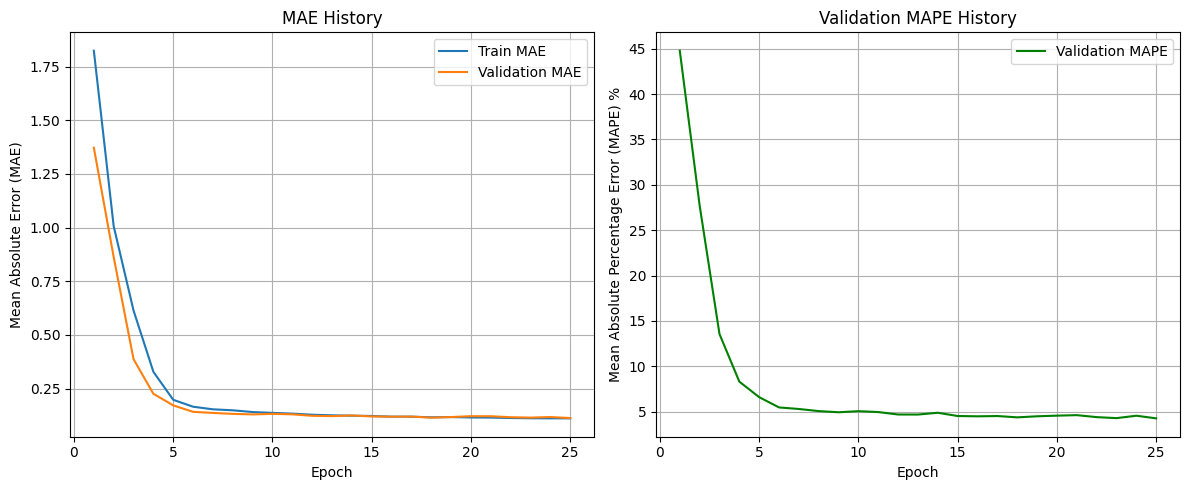

In [16]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt # For plotting losses later

# --- Ensure previous components are defined or imported ---
# Assuming SeismicDataset, BaselineUNet classes are defined in previous cells
# or imported from a utility script.

# --- MAPE Calculation Utility Function (from your utils.py) ---
def calculate_mape(vel_gt: np.ndarray, vel_pred: np.ndarray) -> float:
    """
    Calculates the Mean Absolute Percentage Error between two 2D NumPy arrays.
    EPSILON is added to the denominator to prevent division by zero.
    Args:
        vel_gt: A 2D NumPy array representing the ground truth values.
        vel_pred: A 2D NumPy array representing the predicted values.
                  Must have the same shape as vel_gt.
    Returns:
        The mean of the normalized absolute errors.
    """
    EPSILON = 1e-8
    absolute_difference = np.abs(vel_gt - vel_pred)
    # Ensure vel_gt in denominator is also abs for safety, though velocities should be positive
    normalized_error = absolute_difference / (np.abs(vel_gt) + EPSILON)
    mape = np.mean(normalized_error) * 100 # MAPE is usually expressed as a percentage
    return mape

# --- Configuration & Paths (from Task 1.1) ---
base_train_data_path = "/content/drive/MyDrive/speed_and_structure_data/"
all_sample_folder_paths = sorted(glob.glob(os.path.join(base_train_data_path, "*")))

if not all_sample_folder_paths:
    print(f"ERROR: No sample folders found. Halting training setup.")
else:
    print(f"Found {len(all_sample_folder_paths)} total samples for dataset setup.")

    # --- 1. Device Configuration ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Dataset and DataLoader Instantiation (from Task 1.2) ---
    train_paths, val_paths = train_test_split(all_sample_folder_paths, test_size=0.2, random_state=42, shuffle=True)

    train_dataset = SeismicDataset(train_paths) # Assumes SeismicDataset is defined
    val_dataset = SeismicDataset(val_paths)     # Assumes SeismicDataset is defined

    batch_size = 8 # Keep it small for now, especially if on CPU or limited GPU VRAM
    num_workers = 0 # Start with 0 for simplicity, increase later if I/O is a bottleneck and GPU is available
    if device.type == 'cuda':
      num_workers = 2 # Can use more workers if GPU is available
      print(f"Using num_workers = {num_workers} for DataLoaders.")


    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory= (device.type == 'cuda') )
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory= (device.type == 'cuda') )

    print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
    print(f"Validation DataLoader: {len(val_dataloader)} batches of size {batch_size}")


    # --- 2. Instantiate Model, Loss Function, Optimizer ---
    n_input_channels = 5
    n_output_channels = 1

    model = BaselineUNet(n_channels_in=n_input_channels, n_channels_out=n_output_channels, bilinear=True).to(device)
    # Assumes BaselineUNet is defined

    # Using MAE Loss as our initial loss for training
    criterion_mae = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=5e-5) # Start with a common learning rate

    print("Model, MAE Loss, and Optimizer instantiated.")

    # --- 3. Training and Validation Loop ---
    num_epochs = 25 # Start with a small number of epochs for initial testing
    best_val_mape = float('inf')
    train_mae_history = []
    val_mae_history = []
    val_mape_history = []

    print(f"\nStarting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train() # Set model to training mode
        running_train_mae = 0.0
        num_train_batches = 0

        for train_inputs, train_targets in train_dataloader:
            train_inputs = train_inputs.to(device)   # (batch, 5, 10001, 31)
            train_targets = train_targets.to(device) # (batch, 1, 300, 1259)

            optimizer.zero_grad() # Zero the parameter gradients

            # Forward pass
            train_outputs = model(train_inputs) # Expected output: (batch, 1, 300, 1259)

            # Calculate MAE loss
            loss_mae = criterion_mae(train_outputs, train_targets)

            # Backward pass and optimize
            loss_mae.backward()
            optimizer.step()

            running_train_mae += loss_mae.item() * train_inputs.size(0) # loss.item() is avg loss for batch
            num_train_batches += 1

        epoch_train_mae = running_train_mae / len(train_dataset)
        train_mae_history.append(epoch_train_mae)

        # --- Validation Phase ---
        model.eval() # Set model to evaluation mode
        running_val_mae = 0.0
        running_val_mape = 0.0
        num_val_batches = 0

        with torch.no_grad(): # Disable gradient calculations for validation
            for val_inputs, val_targets in val_dataloader:
                val_inputs = val_inputs.to(device)
                val_targets_torch = val_targets.to(device) # PyTorch tensor for MAE loss

                val_outputs_torch = model(val_inputs)

                # Calculate MAE loss (on PyTorch tensors)
                loss_val_mae = criterion_mae(val_outputs_torch, val_targets_torch)
                running_val_mae += loss_val_mae.item() * val_inputs.size(0)

                # Prepare for MAPE calculation (NumPy arrays)
                # Model output is (N, 1, H, W), target from loader is also (N, 1, H, W)
                # For calculate_mape, we need (N, H, W) or iterate sample by sample
                # Squeeze the channel dimension before converting to NumPy
                val_outputs_np = val_outputs_torch.squeeze(1).cpu().numpy()
                val_targets_np = val_targets_torch.squeeze(1).cpu().numpy()

                current_batch_mape = 0.0
                for i in range(val_outputs_np.shape[0]): # Iterate over samples in the batch
                    # calculate_mape expects 2D arrays (H, W)
                    current_batch_mape += calculate_mape(val_targets_np[i], val_outputs_np[i])

                # Average MAPE for the batch and scale by batch size (as mape is per sample)
                running_val_mape += (current_batch_mape / val_outputs_np.shape[0]) * val_inputs.size(0)
                num_val_batches +=1

        epoch_val_mae = running_val_mae / len(val_dataset)
        epoch_val_mape = running_val_mape / len(val_dataset) # Already scaled by batch size contributions
        val_mae_history.append(epoch_val_mae)
        val_mape_history.append(epoch_val_mape)
        if epoch_val_mape < best_val_mape:
            best_val_mape = epoch_val_mape
            torch.save(model.state_dict(), 'baseline_unet_best_mape-second.pth')
            print(f"Epoch {epoch+1}: New best Val MAPE: {best_val_mape:.4f}%. Model saved.")
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train MAE: {epoch_train_mae:.6f} | "
              f"Val MAE: {epoch_val_mae:.6f} | "
              f"Val MAPE: {epoch_val_mape:.4f}%")

    print("\nFinished Training.")

    # --- Plotting training history (Optional) ---
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_mae_history, label='Train MAE')
    plt.plot(range(1, num_epochs + 1), val_mae_history, label='Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.title('MAE History')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), val_mape_history, label='Validation MAPE', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Percentage Error (MAPE) %')
    plt.title('Validation MAPE History')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### Visualizing a Sample: Seismic Survey Data and Velocity Model

Below, we visualize the **seismic survey data** (i.e., receiver data) for a selected sample, along with its corresponding **ground-truth velocity model**.

The goal of this challenge is to develop a model that takes the **five receiver data inputs** (shown in the left five plots) and predicts the **velocity model** (shown in the rightmost plot). In essence, the task is to learn a mapping from seismic recordings to the underlying subsurface velocity structure.


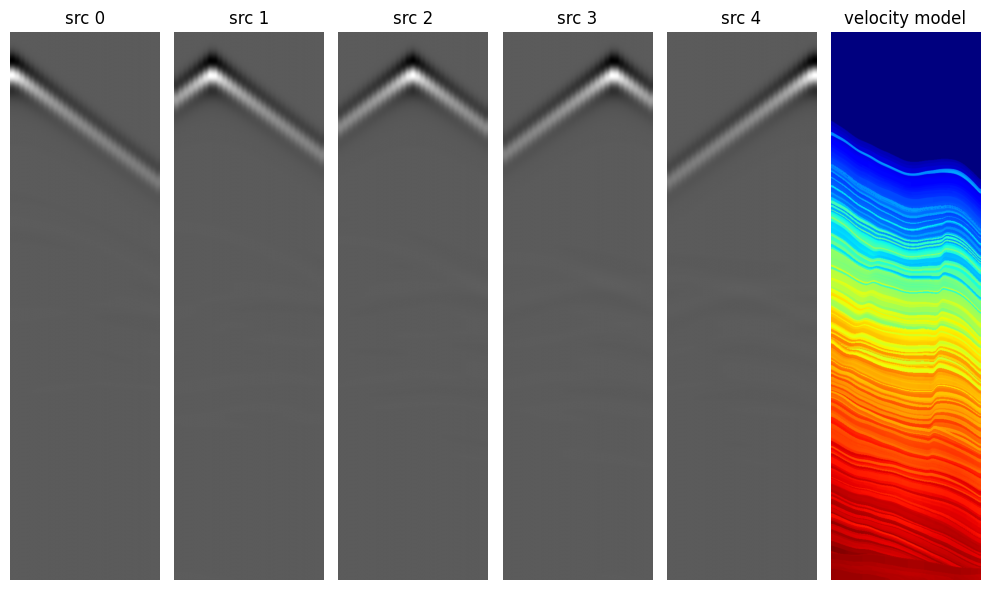

In [ ]:
# Plot one dataset sample
sample_path = sample_paths[0]

source_coordinates = [1, 75, 150, 225, 300]

f, ax = plt.subplots(1, 6, figsize=(10, 6))

for i, s in enumerate(source_coordinates):
    rec_data = np.load(os.path.join(sample_path, f"receiver_data_src_{s}.npy"))
    ax[i].imshow(rec_data, cmap="gray", aspect="auto")
    ax[i].set_title(f"src {i}")
    ax[i].axis("off")

target_data = np.load(os.path.join(sample_path, "vp_model.npy"))
ax[-1].imshow(target_data.T, cmap="jet", aspect="auto")
ax[-1].set_title("velocity model")
ax[-1].axis("off")

plt.tight_layout()
plt.show()

## Your Solution
Your task is summarized below.

**Objective:**  
Develop a model that takes seismic receiver data as input and predicts the corresponding subsurface velocity model.

**Input:**  
- Five 2D NumPy arrays, each with shape **(10001, 31)**  
- These arrays represent receiver data and are of type `numpy.float32`

**Output:**  
- A single 2D NumPy array with shape **(300, 1259)**  
- This array represents the predicted velocity model and **must** be of type `numpy.float64`



# Submission File Format and Instructions


To calculate your score on the predictive leaderboard, your submission must be an `.npz` file containing **150 arrays**, each representing a predicted velocity model for a test sample.

- **Array Naming:** Each array should be named using the **sample ID** from the test dataset.  
  (As explained earlier, sample IDs are the names of the folders containing the corresponding test data.)
- **Array Content:** Each array should be your model's predicted **velocity model** for that sample.
- **Data Type:** All arrays must be of type `numpy.float64`.
- **File Structure:** Your `.npz` file must contain **exactly 150 items**, one for each test sample.

---

### Creating the Submission File

To help you generate the `.npz` submission file, we provide a utility function called `create_submission()` in the `utils.py` module. This function accepts:
- A **sample ID** (as a string)
- A **velocity model array** (as a NumPy array)

You can use this function in a loop to populate your submission file with predictions for all 150 test samples.

> **Important Note:**  
> If you choose not to use the provided `create_submission()` function, ensure that your `.npz` file strictly follows the required format. A sample submission file is also provided for reference.

---

### Demonstration

Below, we demonstrate how to use the `create_submission()` function in combination with a dummy prediction function, `dummy_prediction()`, to generate a sample submission file.  
For demonstration purposes, this example uses only **4 test samples**.


In [ ]:
test_dataset = "/content/drive/MyDrive/speed_and_structure_datatest/*"  # 'path to your test data'
sample_paths = glob(test_dataset)
print("Number of test samples:", len(sample_paths))

for sample_path in sample_paths:

    sample_id = sample_path.split("/")[-1]
    print("\nSample ID:", sample_id)

    # Load input data
    source_coordinates = [1, 75, 150, 225, 300]
    rec_data = [
        np.load(os.path.join(sample_path, f"receiver_data_src_{i}.npy"))
        for i in source_coordinates
    ]

    # Generates a dummy velocity model prediction.
    # This line should be changed to your actual trained model for velocity model prediction
    prediction = dummy_prediction(rec_data, output_shape=(300, 1259))
    print("Prediction shape:", prediction.shape)

    # this line creates/update the submission .npz file and populates it with sample IDs and velocity model prediction
    create_submission(
        sample_id, prediction, "speed-and-structure-dummy-submission1.npz"
    )

Number of test samples: 150

Sample ID: 0BFqBxnVIT368FwmdR
Prediction shape: (300, 1259)

Sample ID: 0yONYjTWNAfKjAilsA
Prediction shape: (300, 1259)

Sample ID: 1Siz5HTYKwwwp6fVn2
Prediction shape: (300, 1259)

Sample ID: 1bxHtxAYD1Kc9Rfz1T
Prediction shape: (300, 1259)

Sample ID: 1jXPNR2ab7iMuw5FS0
Prediction shape: (300, 1259)

Sample ID: 1ke656OijGVH9zF8lI
Prediction shape: (300, 1259)

Sample ID: 20TqVh64gfLMvyxxlB
Prediction shape: (300, 1259)

Sample ID: 3f7qHOhgSRAZeiaMb5
Prediction shape: (300, 1259)

Sample ID: 41tuiYAbTymQ6llvvZ
Prediction shape: (300, 1259)

Sample ID: 4CYRYR4RNJPrq3Ryvk
Prediction shape: (300, 1259)

Sample ID: 55kVju0ebqKwkgLZun
Prediction shape: (300, 1259)

Sample ID: 5Wdpqgax7dDz4LqAgJ
Prediction shape: (300, 1259)

Sample ID: 5nlLlVr1BkECZRIw3e
Prediction shape: (300, 1259)

Sample ID: 5sOXYn8I3yTIxzZ12A
Prediction shape: (300, 1259)

Sample ID: 6OCex6oLG1vtRf559W
Prediction shape: (300, 1259)

Sample ID: 6aUNjG4wIYP7HLbtpU
Prediction shape: (300, 12

# Evaluation Metric: Mean Absolute Percentage Error (MAPE)

Model performance is evaluated using the **Mean Absolute Percentage Error (MAPE)**. For each test sample, MAPE is computed between your predicted velocity model and the ground-truth model using the following formula:

$$
\text{MAPE} = \frac{1}{N} \sum_{i,j} \left| \frac{g(i,j) - p(i,j)}{g(i,j)} \right|
$$

Where:
- $N$ is the total number of elements in the velocity model array  
- $g(i,j)$ is the ground-truth velocity at position $(i, j)$  
- $p(i,j)$ is the predicted velocity at the same position  
- Note: $g(i,j) > 0$ for all $(i, j)$

After computing MAPE for each of the 150 test samples, the final leaderboard score is obtained by averaging the MAPE values across all samples.

---

### Utility Functions for Evaluation

To help you better understand how your predictive leaderboard score is calculated, two utility functions are provided in the `utils.py` module:

1. **`calculate_mape()`**  
   Computes the MAPE for a single sample, given the ground-truth and predicted velocity models.

2. **`calculate_score()`**  
   Accepts the ground-truth and submission `.npz` files, calculates the MAPE for each sample, and returns the average MAPE as your final score.

---

### Demonstration

Below, we demonstrate the use of `calculate_score()` by applying it to two dummy `.npz` submission files. These files were generated using the loop described earlier. One file is treated as the ground-truth, and the other as the prediction.


In [ ]:
answerkey_file = "./speed-and-structure-dummy-submission1.npz"
submission_file = "./speed-and-structure-dummy-submission2.npz"

calculate_score(answerkey_file, submission_file)

0.603278655387954

And the error will obviously be zero if the ground-truth and prediction arrays are exactly the same!

In [ ]:
calculate_score(answerkey_file, answerkey_file)

0.0

# Submission Requirements and Guidelines for Smooth Evaluation

To ensure that your submission can be evaluated smoothly and efficiently, please follow these guidelines. Adhering to these best practices will help us run your code without issues and will also reflect positively on your submission. Failure to comply with these best practices may result in disqualification or delays in the evaluation of your submission.

#### 1. Documentation
- **README Files**: Include a README.md file that provides an overview of your project, instructions on how to run your code, and any other relevant information.
- **Docstrings**: Ensure that all functions and classes have clear and concise docstrings explaining their purpose and usage.
- **Markdown Cells**: Use markdown cells in your Jupyter Notebook to explain the steps of your workflow, the rationale behind your choices, and any important details.

#### 2. Environment Management
- **Document the Environment**: Clearly document the computing environment, including the operating system, Python version, and any other relevant details.
- **Dependencies**: Provide a detailed list of all required libraries and their versions in a `requirements.txt` file.
- **Reproducibility**: Before submission, create a clean environment using your `requirements.txt` file and ensure that your code runs without errors in this environment.

#### 3. Folder Organization and Code Modularity
- **Folder Structure**: Organize your project files logically. Separate scripts, data, models, and documentation into distinct folders.
- **Modular Code**: Write modular code by separating different stages of your workflow (e.g., data loading, preprocessing, training, inference) into distinct functions or modules.
- **Avoid Hard-Coding Paths**: Avoid hard-coding paths, especially data paths. Use variables for data path or configuration files to specify paths, ensuring that your code can run on different machines without modification.

#### 4. Workflow Orchestration
- **Main Script**: Use a main Jupyter Notebook to orchestrate the workflow. This Notebook should call the necessary functions or modules in the correct order and provide a clear overview of the entire process.

#### 5. Model Checkpoints
- **Save Checkpoints**: Save and include trained model checkpoints in your submission.
- **Instructions**: Provide clear instructions on how to save, load, and use the model checkpoints, preferably in your README.md file.

#### 6. Double-Check Files
- **Include Necessary Files**: Ensure that all necessary files are included in your submission. This includes the license, notebook, `requirements.txt`, model checkpoints, and any other essential files.
- **Exclude Unnecessary Files**: Exclude unnecessary files such as training and test data to keep your submission clean and focused, and smaller in size.


# Final Evaluation Criteria

If you are selected to send your code and files for the final evaluation, 90% of your final score will be based on your model's MAPE score on the private holdout dataset. The remaining 10% will depend on how well you follow the above-mentioned guidelines. This means that thorough documentation, proper environment management, good folder organization, modular code, and the inclusion of all necessary files are crucial for your success.


To highlight and encourage innovation in this challenge, we are offering **two honorable mentions**—each accompanied by **prize money**—for the **top two most novel and valid approaches** submitted. These awards aim to recognize creative strategies that go beyond conventional solutions, regardless of leaderboard ranking.


By strictly following these guidelines, you will help us evaluate your submission more effectively and increase the chances of your work being recognized. Non-compliance with these requirements may lead to your submission being rejected or not evaluated properly. <b>Thank you for your attention to details and good luck with the challenge!</b>